# HR Analytics - Attrition Analysis

Analysis of employee attrition patterns using Pandas, focusing on identifying key factors driving employee departures.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Load Data

In [2]:
df = pd.read_csv('HR_Analytics.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (1480, 38)


,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0


## Data Quality Check

In [3]:
# Quick data validation
print(df.info())
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmpID                     1480 non-null   object 
 1   Age                       1480 non-null   int64  
 2   AgeGroup                  1480 non-null   object 
 3   Attrition                 1480 non-null   object 
 4   BusinessTravel            1480 non-null   object 
 5   DailyRate                 1480 non-null   int64  
 6   Department                1480 non-null   object 
 7   DistanceFromHome          1480 non-null   int64  
 8   Education                 1480 non-null   int64  
 9   EducationField            1480 non-null   object 
 10  EmployeeCount             1480 non-null   int64  
 11  EmployeeNumber            1480 non-null   int64  
 12  EnvironmentSatisfaction   1480 non-null   int64  
 13  Gender                    1480 non-null   object 
 14  HourlyRa

## Overall Attrition Rate

In [4]:
# Get baseline attrition
attrition_rate = (df['Attrition'].value_counts(normalize=True) * 100).round(2)
print(attrition_rate)
print(f"\nTotal employees: {len(df)}")
print(f"Left: {(df['Attrition'] == 'Yes').sum()}")
print(f"Stayed: {(df['Attrition'] == 'No').sum()}")

Attrition
No     83.92
Yes    16.08
Name: proportion, dtype: float64

Total employees: 1480
Left: 238
Stayed: 1242


## Department Analysis

Looking at attrition by department to see if some units are hit harder than others.

In [5]:
dept_analysis = (
    df.groupby('Department')
    .agg({
        'EmpID': 'count',
        'MonthlyIncome': 'mean',
        'TotalWorkingYears': 'mean',
        'Attrition': lambda x: (x == 'Yes').mean() * 100
    })
    .rename(columns={'EmpID': 'Count', 'MonthlyIncome': 'AvgSalary', 
                     'TotalWorkingYears': 'AvgExp', 'Attrition': 'AttritionRate'})
    .round(2)
    .sort_values('AttritionRate', ascending=False)
)
print(dept_analysis)

                        Count  AvgSalary  AvgExp  AttritionRate
Department                                                     
Sales                     450    6966.74   11.15          20.67
Human Resources            63    6654.51   11.56          19.05
Research & Development    967    6280.37   11.33          13.75


C:\Users\ranja\AppData\Local\Temp\ipykernel_11560\1181483201.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_attrition.index, y=dept_attrition.values, palette='Set2', ax=ax)


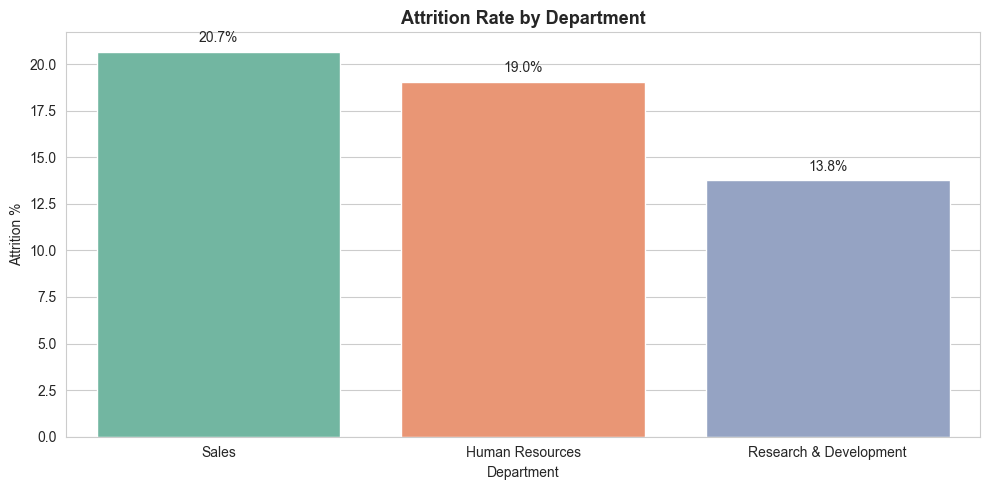

In [6]:
# Department attrition visualization
dept_attrition = (
    df.groupby('Department')['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=dept_attrition.index, y=dept_attrition.values, palette='Set2', ax=ax)
ax.set_title('Attrition Rate by Department', fontsize=13, fontweight='bold')
ax.set_ylabel('Attrition %')
ax.set_xlabel('Department')
for i, v in enumerate(dept_attrition.values):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

## Demographics

In [7]:
# Gender breakdown
print(pd.crosstab(df['Gender'], df['Attrition'], margins=True))
print()

gender_rate = (
    df.groupby('Gender')['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .round(2)
)
print("Attrition by gender:")
print(gender_rate)

Attrition    No  Yes   All
Gender                    
Female      504   87   591
Male        738  151   889
All        1242  238  1480

Attrition by gender:
Gender
Female    14.72
Male      16.99
Name: Attrition, dtype: float64


## Overtime Impact

This is interesting - checking if employees working overtime have different attrition patterns.

In [8]:
# Overtime analysis
overtime_analysis = (
    df.groupby('OverTime')
    .agg({'EmpID': 'count', 'Attrition': lambda x: (x == 'Yes').mean() * 100})
    .rename(columns={'EmpID': 'Count', 'Attrition': 'AttritionRate'})
    .round(2)
)
print(overtime_analysis)
print(f"\nDifference: {overtime_analysis.loc['Yes', 'AttritionRate'] - overtime_analysis.loc['No', 'AttritionRate']:.1f} percentage points")

          Count  AttritionRate
OverTime                      
No         1062          10.36
Yes         418          30.62

Difference: 20.3 percentage points


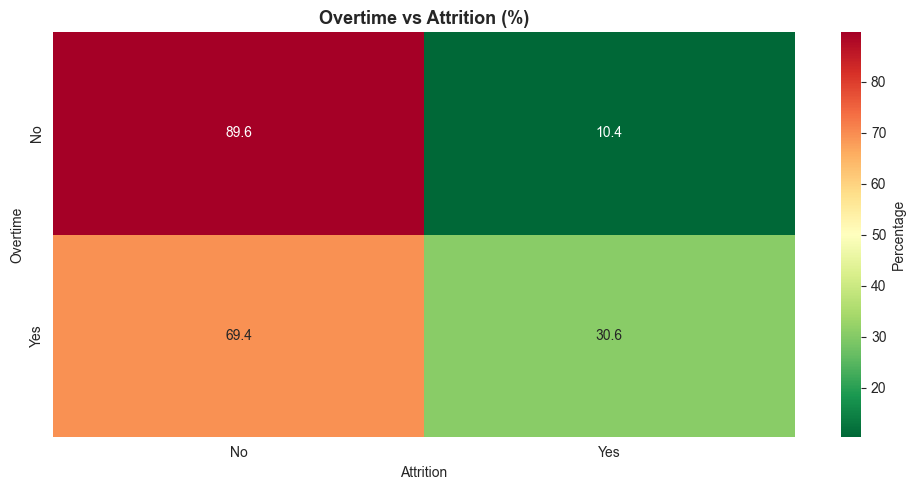

In [9]:
# Overtime impact chart
overtime_pct = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(overtime_pct, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax, cbar_kws={'label': 'Percentage'})
ax.set_title('Overtime vs Attrition (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Overtime')
ax.set_xlabel('Attrition')
plt.tight_layout()
plt.show()

## Salary Analysis

Checking if compensation is linked to attrition.

In [10]:
# Salary band analysis
salary_analysis = (
    df.groupby('SalarySlab')
    .agg({'EmpID': 'count', 'MonthlyIncome': 'mean', 'Attrition': lambda x: (x == 'Yes').mean() * 100})
    .rename(columns={'EmpID': 'Count', 'MonthlyIncome': 'AvgIncome', 'Attrition': 'AttritionRate'})
    .round(2)
    .sort_values('AttritionRate', ascending=False)
)
print(salary_analysis)

            Count  AvgIncome  AttritionRate
SalarySlab                                 
Upto 5k       753    3190.84          21.65
10k-15k       150   11914.51          14.00
5k-10k        444    6836.95          11.04
15k+          133   18059.36           3.76


C:\Users\ranja\AppData\Local\Temp\ipykernel_11560\666910602.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=salary_attrition.index, y=salary_attrition.values, palette='viridis', ax=ax)


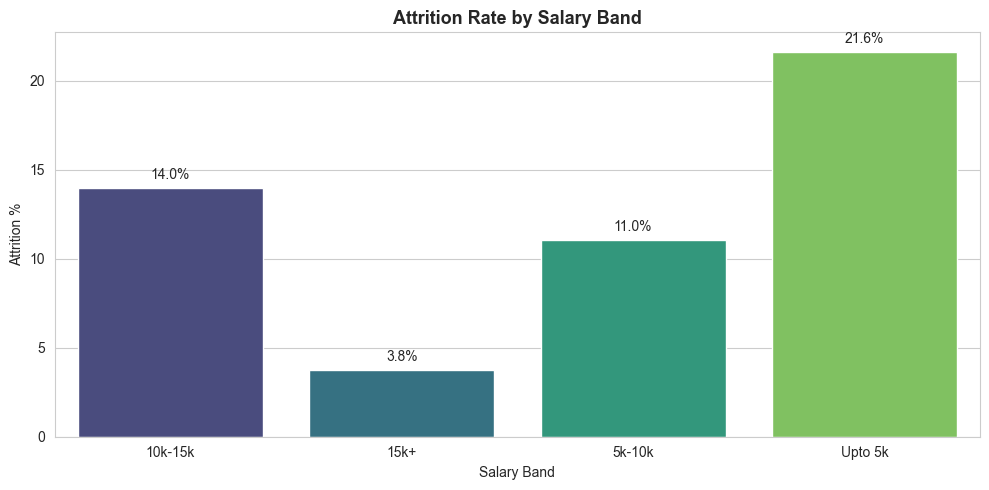

In [11]:
# Salary band visualization
salary_attrition = (
    df.groupby('SalarySlab')['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=salary_attrition.index, y=salary_attrition.values, palette='viridis', ax=ax)
ax.set_title('Attrition Rate by Salary Band', fontsize=13, fontweight='bold')
ax.set_ylabel('Attrition %')
ax.set_xlabel('Salary Band')
for i, v in enumerate(salary_attrition.values):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

## Job Roles

In [12]:
# Job role attrition
jobrole_analysis = (
    df.groupby('JobRole')
    .agg({'EmpID': 'count', 'MonthlyIncome': 'mean', 'Attrition': lambda x: (x == 'Yes').mean() * 100})
    .rename(columns={'EmpID': 'Count', 'MonthlyIncome': 'AvgSalary', 'Attrition': 'AttritionRate'})
    .round(2)
    .sort_values('AttritionRate', ascending=False)
)
print(jobrole_analysis)

                           Count  AvgSalary  AttritionRate
JobRole                                                   
Sales Representative          84    2630.05          39.29
Laboratory Technician        261    3239.09          23.75
Human Resources               52    4235.75          23.08
Sales Executive              329    6947.08          17.63
Research Scientist           293    3241.83          16.04
Healthcare Representative    132    7547.42           6.82
Manufacturing Director       147    7305.26           6.80
Manager                      102   17181.68           4.90
Research Director             80   16033.55           2.50


## Work-Life Balance

In [13]:
# Work-life balance vs attrition
worklife = pd.pivot_table(
    df, 
    values='EmpID', 
    index='WorkLifeBalance', 
    columns='Attrition', 
    aggfunc='count', 
    fill_value=0
)
print(worklife)
print()

# Attrition rate by satisfaction
worklife_rate = (
    df.groupby('WorkLifeBalance')['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .round(2)
)
print("Attrition rate by work-life balance score:")
print(worklife_rate)
print("(1=Low satisfaction, 4=High satisfaction)")

Attrition         No  Yes
WorkLifeBalance          
1                 56   25
2                288   58
3                771  128
4                127   27

Attrition rate by work-life balance score:
WorkLifeBalance
1    30.86
2    16.76
3    14.24
4    17.53
Name: Attrition, dtype: float64
(1=Low satisfaction, 4=High satisfaction)


## Experience Bands

Segmenting employees by career stage to see if early/mid/senior levels have different attrition.

In [14]:
# Create experience bands
df['ExperienceBand'] = pd.cut(
    df['TotalWorkingYears'],
    bins=[0, 5, 10, 20, 50],
    labels=['0-5 yrs', '6-10 yrs', '11-20 yrs', '20+ yrs']
)

# Analyze by band
experience = (
    df.groupby('ExperienceBand')
    .agg({'EmpID': 'count', 'Attrition': lambda x: (x == 'Yes').mean() * 100})
    .rename(columns={'EmpID': 'Count', 'Attrition': 'AttritionRate'})
    .round(2)
)
print(experience)

                Count  AttritionRate
ExperienceBand                      
0-5 yrs           307          28.01
6-10 yrs          611          14.89
11-20 yrs         343          11.66
20+ yrs           208           7.69


C:\Users\ranja\AppData\Local\Temp\ipykernel_11560\549438409.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('ExperienceBand')


## What Factors Correlate with Attrition?

Looking at correlation to understand which numeric variables have strongest relationship with attrition.

In [15]:
# Prepare data for correlation
df_corr = df.copy()
df_corr['Attrition_Numeric'] = (df_corr['Attrition'] == 'Yes').astype(int)

# Get correlations
numeric_cols = df_corr.select_dtypes(include=['number']).columns
attrition_corr = df_corr[numeric_cols].corr()['Attrition_Numeric'].sort_values()

print("\nTop factors (negative = reduce attrition):")
print(attrition_corr.head(8).to_string())
print("\nTop factors (positive = increase attrition):")
print(attrition_corr.tail(8).to_string())


Top factors (negative = reduce attrition):
TotalWorkingYears      -0.168358
JobLevel               -0.167150
YearsWithCurrManager   -0.163367
YearsInCurrentRole     -0.160968
MonthlyIncome          -0.157672
Age                    -0.155476
StockOptionLevel       -0.135140
YearsAtCompany         -0.135108

Top factors (positive = increase attrition):
HourlyRate           -0.008252
PerformanceRating     0.002531
MonthlyRate           0.016585
NumCompaniesWorked    0.045336
DistanceFromHome      0.080006
Attrition_Numeric     1.000000
EmployeeCount              NaN
StandardHours              NaN


C:\Users\ranja\AppData\Local\Temp\ipykernel_11560\3438202313.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_corr.index, x=top_corr.values, palette=colors, ax=ax)


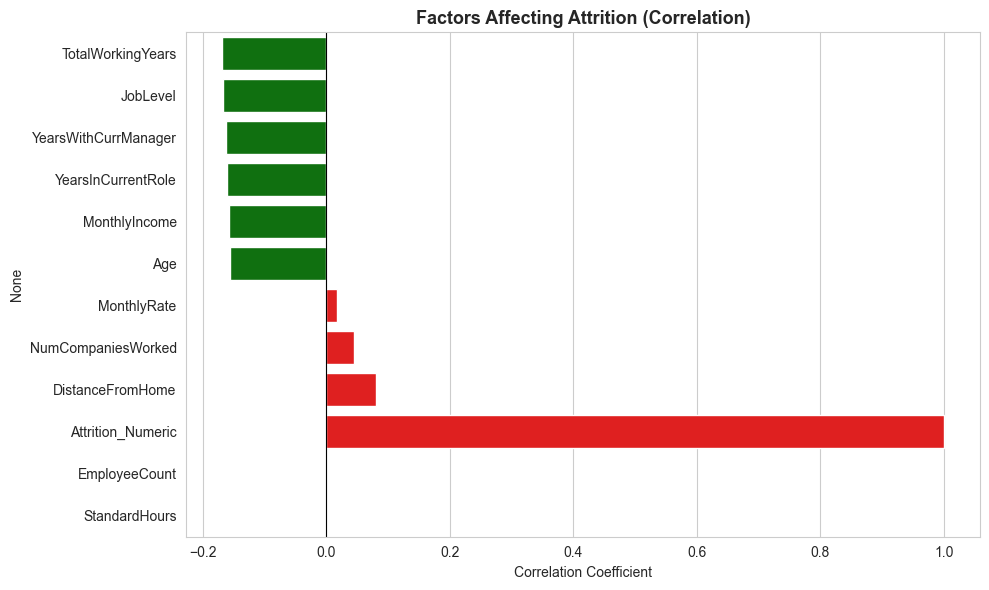

In [16]:
# Visualize top correlations
top_corr = pd.concat([attrition_corr.head(6), attrition_corr.tail(6)])

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['red' if x > 0 else 'green' for x in top_corr.values]
sns.barplot(y=top_corr.index, x=top_corr.values, palette=colors, ax=ax)
ax.set_title('Factors Affecting Attrition (Correlation)', fontsize=13, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.tight_layout()
plt.show()

## Key Takeaways

**Main Drivers of Attrition:**
1. **Overtime** - Huge difference (30% vs 10% attrition)
2. **Salary** - Lower bands have higher attrition
3. **Department** - Sales/R&D more affected
4. **Work-Life Balance** - Lower scores correlate with leaving
5. **Early Career** - 0-5 years group most at risk

**What This Means:**
- Overtime is the most controllable lever - reducing it could have immediate impact
- Compensation review needed for lower bands
- Focus retention efforts on Sales/R&D
- Improve workplace conditions and work-life balance
- Strengthen onboarding for new hires

# Employee Attrition Prediction using Logistic Regression

After performing exploratory data analysis and identifying key factors affecting employee attrition, a Logistic Regression model was developed to predict whether an employee is likely to leave the company.

The objective is to help HR teams proactively identify high-risk employees and take retention measures.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
print("All ML libraries imported successfully!")

All ML libraries imported successfully!


In [18]:
# Create a clean copy for ML
ml_df = df.copy()

# Drop columns that add no predictive value
cols_to_drop = ['EmpID', 'EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours', 'AgeGroup', 'SalarySlab', 'ExperienceBand']
ml_df.drop(columns=cols_to_drop, inplace=True)

print(f"Dataset shape after cleanup: {ml_df.shape}")
print(f"Remaining columns: {ml_df.columns.tolist()}")

Dataset shape after cleanup: (1480, 31)
Remaining columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [19]:
# Identify all text (categorical) columns
categorical_cols = ml_df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns to encode: {categorical_cols}")

# Apply Label Encoding to each text column
le = LabelEncoder()
for col in categorical_cols:
    ml_df[col] = le.fit_transform(ml_df[col])

print("\n✅ Label Encoding complete!")
print(f"\nSample of encoded data:")
ml_df.head(3)

Categorical columns to encode: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

✅ Label Encoding complete!

Sample of encoded data:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,18,1,3,230,1,3,3,1,3,1,...,3,3,0,0,2,3,0,0,0,0.0
1,18,0,3,812,2,10,3,3,4,0,...,3,1,0,0,2,3,0,0,0,0.0
2,18,1,2,1306,2,5,3,2,2,1,...,3,4,0,0,3,3,0,0,0,0.0


In [20]:
# X = all columns EXCEPT Attrition
X = ml_df.drop(columns=['Attrition'])

# y = the Attrition column (what we want to predict)
y = ml_df['Attrition']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape:   {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts().rename({0: 'Stayed (0)', 1: 'Left (1)'}))

Features (X) shape: (1480, 30)
Target (y) shape:   (1480,)

Target distribution:
Attrition
Stayed (0)    1242
Left (1)       238
Name: count, dtype: int64


In [21]:
X['YearsWithCurrManager'] = X['YearsWithCurrManager'].fillna(
    X['YearsWithCurrManager'].median()
)

In [22]:
# Split the data — 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print(f"Training set size:  {X_train.shape[0]} employees")
print(f"Testing set size:   {X_test.shape[0]} employees")
print(f"\nTraining Attrition split:\n{y_train.value_counts().rename({0:'Stayed', 1:'Left'})}")
print(f"\nTesting Attrition split:\n{y_test.value_counts().rename({0:'Stayed', 1:'Left'})}")

Training set size:  1184 employees
Testing set size:   296 employees

Training Attrition split:
Attrition
Stayed    993
Left      191
Name: count, dtype: int64

Testing Attrition split:
Attrition
Stayed    249
Left       47
Name: count, dtype: int64


In [24]:
# Initialize the model
model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model on training data
model.fit(X_train, y_train)

print("✅ Model trained successfully!")
print("\nThe model has learned patterns from", X_train.shape[0], "employee records.")


✅ Model trained successfully!

The model has learned patterns from 1184 employee records.


C:\Users\ranja\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [25]:
# Predict on the test set
y_pred = model.predict(X_test)

# Quick preview
print("Sample predictions vs actual:")
comparison = pd.DataFrame({'Actual': y_test.values[:10], 'Predicted': y_pred[:10]})
comparison['Match'] = comparison['Actual'] == comparison['Predicted']
comparison['Actual'] = comparison['Actual'].map({1:'Left', 0:'Stayed'})
comparison['Predicted'] = comparison['Predicted'].map({1:'Left', 0:'Stayed'})
print(comparison.to_string(index=False))

Sample predictions vs actual:
Actual Predicted  Match
Stayed    Stayed   True
Stayed    Stayed   True
  Left      Left   True
Stayed    Stayed   True
Stayed    Stayed   True
Stayed    Stayed   True
Stayed    Stayed   True
Stayed    Stayed   True
  Left    Stayed  False
Stayed    Stayed   True


In [26]:
# Calculate all evaluation metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("="*45)
print("       MODEL PERFORMANCE METRICS")
print("="*45)
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision : {precision:.4f}  ({precision*100:.2f}%)")
print(f"  Recall    : {recall:.4f}  ({recall*100:.2f}%)")
print(f"  F1 Score  : {f1:.4f}  ({f1*100:.2f}%)")
print("="*45)

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))

       MODEL PERFORMANCE METRICS
  Accuracy  : 0.8649  (86.49%)
  Precision : 0.6667  (66.67%)
  Recall    : 0.2979  (29.79%)
  F1 Score  : 0.4118  (41.18%)

Detailed Classification Report:
              precision    recall  f1-score   support

      Stayed       0.88      0.97      0.92       249
        Left       0.67      0.30      0.41        47

    accuracy                           0.86       296
   macro avg       0.77      0.63      0.67       296
weighted avg       0.85      0.86      0.84       296



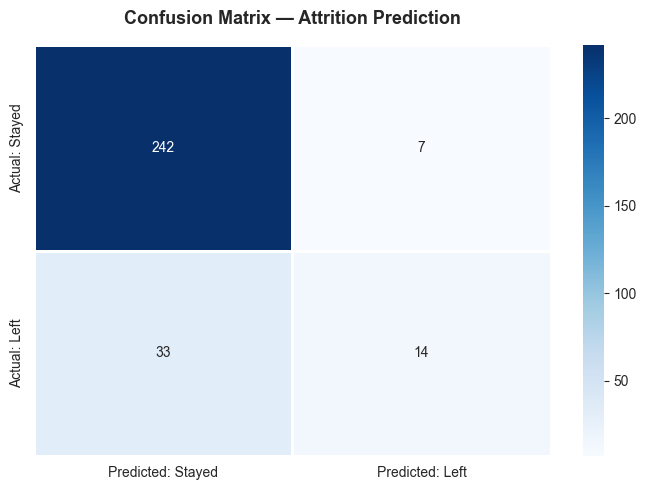


Reading the matrix:
  True Negatives  (Stayed, predicted Stayed): 242
  False Positives (Stayed, predicted Left  ): 7
  False Negatives (Left,   predicted Stayed): 33  ← Employees we MISSED
  True Positives  (Left,   predicted Left  ): 14  ← Employees correctly flagged


In [27]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted: Stayed', 'Predicted: Left'],
    yticklabels=['Actual: Stayed', 'Actual: Left'],
    linewidths=1,
    ax=ax
)
ax.set_title('Confusion Matrix — Attrition Prediction', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print(f"\nReading the matrix:")
print(f"  True Negatives  (Stayed, predicted Stayed): {cm[0][0]}")
print(f"  False Positives (Stayed, predicted Left  ): {cm[0][1]}")
print(f"  False Negatives (Left,   predicted Stayed): {cm[1][0]}  ← Employees we MISSED")
print(f"  True Positives  (Left,   predicted Left  ): {cm[1][1]}  ← Employees correctly flagged")

In [28]:
# Extract coefficients from the model
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

# Sort by absolute importance
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False).reset_index(drop=True)

print("Top 15 Most Important Features:")
print(coef_df[['Feature', 'Coefficient']].head(15).to_string(index=False))

Top 15 Most Important Features:
                Feature  Coefficient
               OverTime     0.527918
          MaritalStatus     0.398203
        JobSatisfaction    -0.378336
EnvironmentSatisfaction    -0.344633
       StockOptionLevel    -0.314220
         JobInvolvement    -0.301224
     YearsInCurrentRole    -0.244913
YearsSinceLastPromotion     0.224016
         BusinessTravel     0.209924
   YearsWithCurrManager    -0.202171
        WorkLifeBalance    -0.150237
         YearsAtCompany     0.145946
                 Gender     0.142992
  TrainingTimesLastYear    -0.129011
     NumCompaniesWorked     0.122097


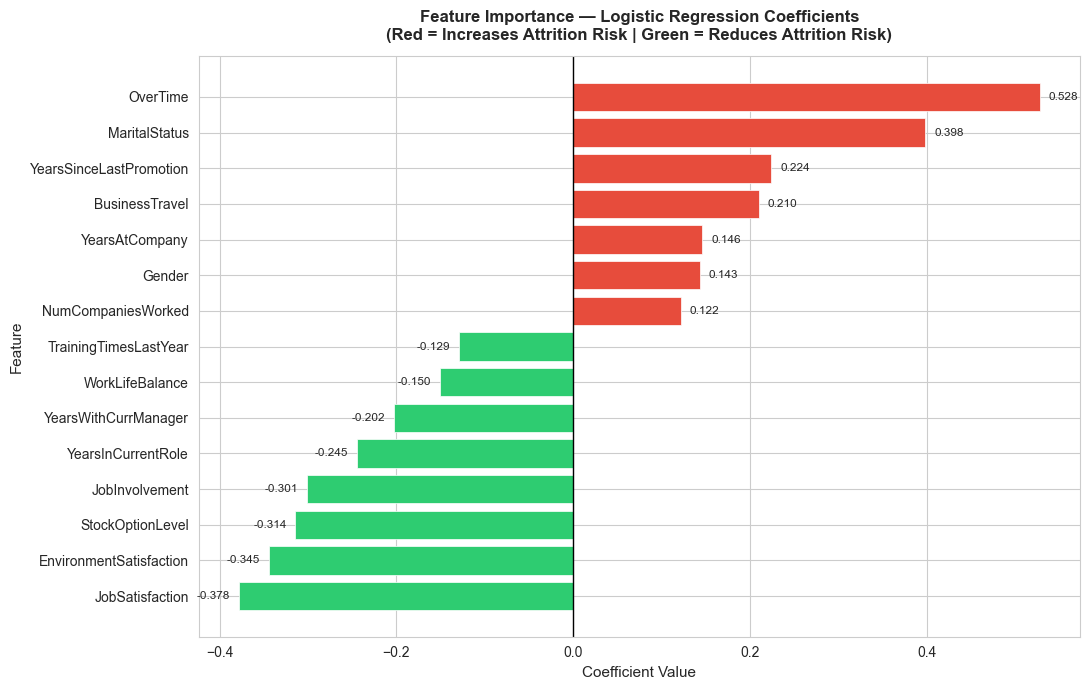

In [29]:
# Visualize feature importance
top15 = coef_df.head(15).sort_values('Coefficient')

colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in top15['Coefficient']]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top15['Feature'], top15['Coefficient'], color=colors, edgecolor='white', linewidth=0.5)

ax.axvline(x=0, color='black', linewidth=1.0, linestyle='-')
ax.set_title('Feature Importance — Logistic Regression Coefficients\n(Red = Increases Attrition Risk | Green = Reduces Attrition Risk)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Coefficient Value', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)

for bar, val in zip(bars, top15['Coefficient']):
    ax.text(val + (0.01 if val >= 0 else -0.01),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}',
            va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=8.5)

plt.tight_layout()
plt.show()

In [31]:
print("""
PROJECT SUMMARY

1. Performed HR Analytics using Python and Pandas.
2. Identified attrition drivers through business analysis.
3. Built Power BI dashboard for workforce insights.
4. Developed Logistic Regression model for attrition prediction.
5. Evaluated using Accuracy, Precision, Recall and F1 Score.
6. Generated recommendations to improve employee retention.
""")


PROJECT SUMMARY

1. Performed HR Analytics using Python and Pandas.
2. Identified attrition drivers through business analysis.
3. Built Power BI dashboard for workforce insights.
4. Developed Logistic Regression model for attrition prediction.
5. Evaluated using Accuracy, Precision, Recall and F1 Score.
6. Generated recommendations to improve employee retention.

